<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Import Needed Libraries</h2>
</div>

In [47]:
import pandas as pd
import nltk
nltk.download('punkt')
import spacy
nlp = spacy.load("en_core_web_sm")
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize , sent_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ahmed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Reading Dataset And Get Info</h2>
</div>

In [2]:
df_Fake = pd.read_csv('Fake.csv')
df_True = pd.read_csv('True.csv')

In [3]:
# Show Sample of Fake News
df_Fake.sample(5)

,title,text,subject,date
14143,NEW YORK VOTERS GET IT: Protesters Let It Rip ...,This is great! Protesters let it rip on Hillary!,politics,"Apr 9, 2016"
18161,"COLLEGE FACES $250,000 FINE For Punishing Pray...",When Columbia University s internal investigat...,left-news,"Aug 12, 2017"
13235,MEDIA IMMEDIATELY REPORTS Alleged Killer Of Im...,There is no question that the killing of any i...,politics,"Aug 16, 2016"
21368,UPDATE: [VIDEO] Bomb Squad Investigating “Subs...,Of course this is the first you ve heard of th...,left-news,"Nov 5, 2015"
23140,The Great Con: Has Political Correctness Margi...,Charles Hugh Smith Of Two MindsSo when the pr...,Middle-east,"November 21, 2016"


In [4]:
# Show Sample of True News
df_True.sample(5)

,title,text,subject,date
21313,New law needed to allow torture victims to sue...,KABUL (Reuters) - Human rights activists are u...,worldnews,"August 27, 2017"
13346,Factbox: Countdown to Brexit breakthrough?,BRUSSELS (Reuters) - The next two weeks will d...,worldnews,"December 1, 2017"
11118,"Vice President Biden, Turkey's Erdogan discuss...",WASHINGTON (Reuters) - The White House said Vi...,politicsNews,"January 25, 2016"
11411,UAE has information Tunisian women may commit ...,TUNIS (Reuters) - The United Arab Emirates has...,worldnews,"December 25, 2017"
11600,Hamas chief in Gaza says Palestinian unity dea...,GAZA (Reuters) - Palestinian Islamist group Ha...,worldnews,"December 21, 2017"


In [5]:
# Show Shape of Fake News Data
print(f"Number of Row : {df_Fake.shape[0]}\nNumber of Columns : {df_Fake.shape[1]}")

Number of Row : 23481
Number of Columns : 4


In [6]:
# Show Shape of True News Data
print(f"Number of Row : {df_True.shape[0]}\nNumber of Columns : {df_True.shape[1]}")

Number of Row : 21417
Number of Columns : 4


In [7]:
# Show Info of Fake News Data
df_Fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [8]:
# Show Info of True News Data
df_True.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [9]:
# Check NaN Value in Fake News Data
df_Fake.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [10]:
# Check NaN Value in True News Data
df_True.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [11]:
# Show Describe of Fake News Data
pd.DataFrame({'Count':df_Fake.shape[0],
              'Null':df_Fake.isnull().sum(),
              'Null %':df_Fake.isnull().mean() * 100,
              'Cardinality':df_Fake.nunique()
})

,Count,Null,Null %,Cardinality
title,23481,0,0.0,17903
text,23481,0,0.0,17455
subject,23481,0,0.0,6
date,23481,0,0.0,1681


In [12]:
# Show Describe of True News Data
pd.DataFrame({'Count':df_True.shape[0],
              'Null':df_True.isnull().sum(),
              'Null %':df_True.isnull().mean() * 100,
              'Cardinality':df_True.nunique()
})

,Count,Null,Null %,Cardinality
title,21417,0,0.0,20826
text,21417,0,0.0,21192
subject,21417,0,0.0,2
date,21417,0,0.0,716


In [13]:
# Check Dublication in Fake News Data
df_Fake.duplicated().sum()

3

In [14]:
# Check Dublication in True News Data
df_True.duplicated().sum()

206

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Data Preprocessing </h2>
</div>

#### Remove Dublication and Clean Date Column

In [15]:
# Drop Dublication in Fake and True News Data
df_Fake.drop_duplicates(inplace=True)
df_True.drop_duplicates(inplace=True)

In [16]:
# Combine Fake and True News Data
df_Fake['label'] = 'Fake'
df_True['label'] = 'True'
df = pd.concat([df_Fake,df_True],axis=0).reset_index(drop=True)

# Combine Title and Text to one Column
df['Content'] = df['title'] + ' ' + df['text']

In [17]:
# Info of Combined Data before drop dublication 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44689 non-null  object
 1   text     44689 non-null  object
 2   subject  44689 non-null  object
 3   date     44689 non-null  object
 4   label    44689 non-null  object
 5   Content  44689 non-null  object
dtypes: object(6)
memory usage: 2.0+ MB


In [18]:
# Check Dublication in Combined Data (Content Column)
df[['Content']].duplicated().sum()

5584

In [19]:
# Drop Dublication in Combined Data (Content Column)
df = df.drop_duplicates(subset=['Content'], keep='first')

In [20]:
# Final Info of Combined Data after drop dublication
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39105 entries, 0 to 44688
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    39105 non-null  object
 1   text     39105 non-null  object
 2   subject  39105 non-null  object
 3   date     39105 non-null  object
 4   label    39105 non-null  object
 5   Content  39105 non-null  object
dtypes: object(6)
memory usage: 2.1+ MB


In [21]:
# Show Shape of Combined Data
print(f"Number of Row : {df.shape[0]}\nNumber of Columns : {df.shape[1]}")

Number of Row : 39105
Number of Columns : 6


In [22]:
# Show Sample of Combined Data
df.head()

,title,text,subject,date,label,Content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake,Pope Francis Just Called Out Donald Trump Dur...


#### Preprocessing Text

In [23]:
# Feature Engineering 
df['No_of_Characters'] = df['Content'].apply(len)
df['No_of_Words'] = df['Content'].apply(lambda x:len(word_tokenize(x)))
df['No_of_Sentences'] = df['Content'].apply(lambda x:len(sent_tokenize(x)))
df.describe()

,No_of_Characters,No_of_Words,No_of_Sentences
count,39105.000000,39105.000000,39105.000000
mean,2505.880629,460.774990,14.989797
std,1943.950515,357.262251,12.011661
min,31.000000,5.000000,1.000000
25%,1348.000000,246.000000,7.000000
50%,2288.000000,422.000000,13.000000
75%,3163.000000,583.000000,20.000000
max,51893.000000,9970.000000,321.000000


<Figure size 1200x800 with 0 Axes>

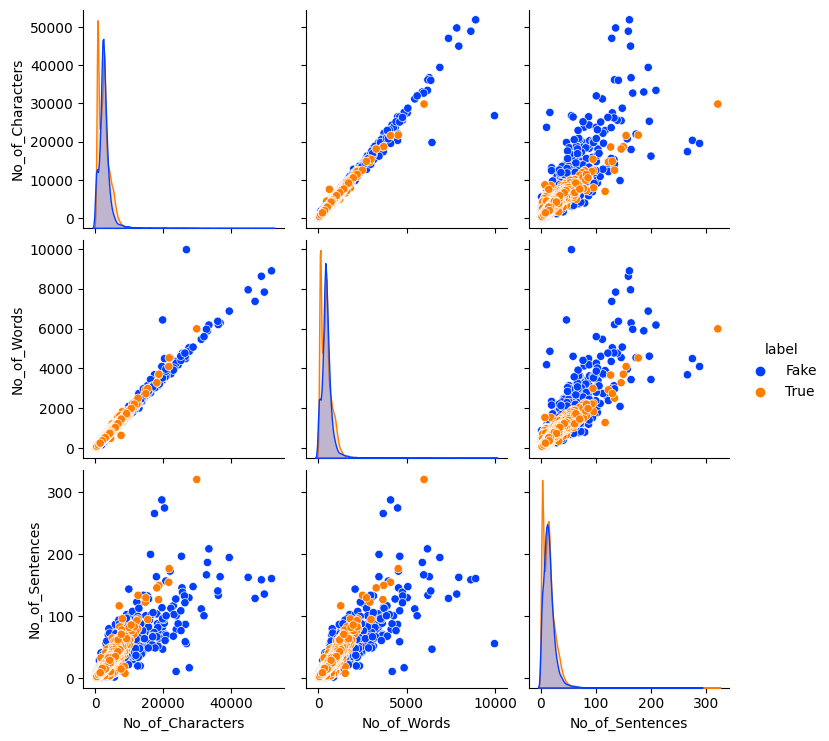

In [24]:
plt.figure(figsize=(12,8))
sns.pairplot(data=df, hue="label",palette="bright")
plt.show()

In [25]:
# Show Distribution of Subject
px.bar(df['subject'].value_counts(),
       title='Distribution of Subject',
       labels={'subject':'Subject','value':'Count'},
       color=df['subject'].value_counts().index,
       template='plotly_dark',
       text_auto=True,
       ).show()

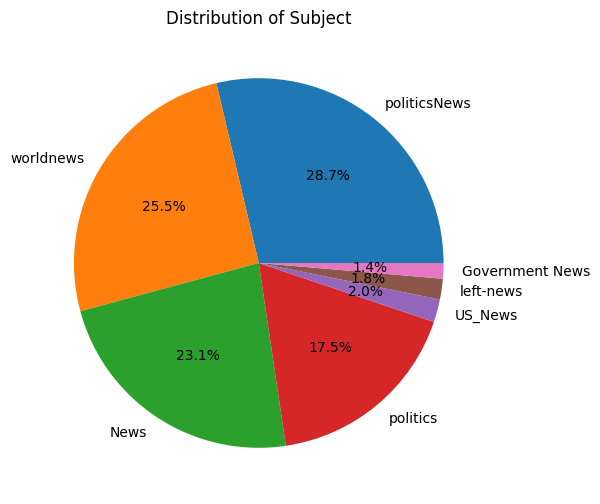

In [26]:
plt.figure(figsize=(12,6))
plt.pie(df['subject'].value_counts(), labels=df['subject'].value_counts().index, autopct='%1.1f%%')
plt.title('Distribution of Subject')
plt.show()

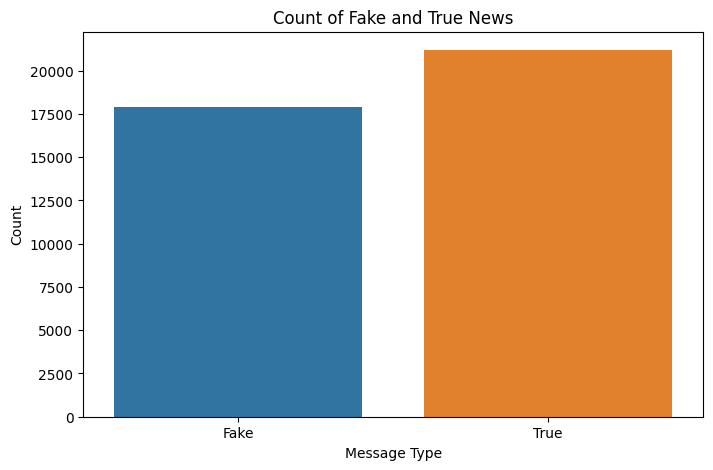

In [27]:
# plot the count of spam and ham messages
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df)
plt.title('Count of Fake and True News')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

- There is Balanced Data for Target

#### Clean Text

In [28]:
def clean(text):
    text = re.sub(r'[^a-zA-Z\d]', ' ', text)
    text = re.sub(r'(https?://\S+|www\.\S+)', '', text)
    text = re.sub(r'\s+', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    doc = nlp(' '.join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return ' '.join(lemmatized)


df['cleanded_text'] = df['Content'].apply(lambda x: clean(x.lower()))

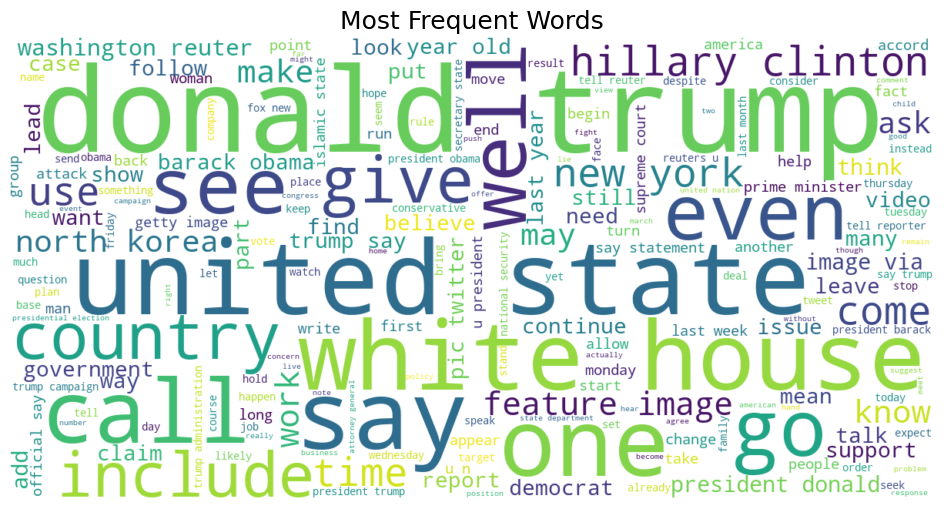

In [29]:
# Generate a WordCloud from cleaned text
all_text = ' '.join(df['cleanded_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',  
    max_words=200
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words", fontsize=18)
plt.show()

<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Model</h2>
</div>

In [ ]:
# Encode Categorical Columns
df['label'] = df['label'].map({'Fake':0,'True':1})
df.head()

,title,text,subject,date,label,Content,No_of_Characters,No_of_Words,No_of_Sentences,cleanded_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...,2973,614,28,donald trump send embarrass new year eve messa...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...,1968,339,11,drunk bragging trump staffer start russian col...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...,3688,706,25,sheriff david clarke become internet joke thre...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...,2853,537,15,trump obsess even obama name code website imag...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...,2417,469,19,pope francis call donald trump christmas speec...


In [40]:
# Split Data
X = df[['cleanded_text']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train Shape :',X_train.shape)
print('X_test Shape :',X_test.shape)
print('y_train Shape :',y_train.shape)
print('y_test Shape :',y_test.shape)

X_train Shape : (31284, 1)
X_test Shape : (7821, 1)
y_train Shape : (31284,)
y_test Shape : (7821,)


In [41]:
# Step 1: TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train['cleanded_text'])
X_test_tfidf = vectorizer.transform(X_test['cleanded_text'])

In [44]:
def train(model ,model_name ,X_train ,y_train ,X_test ,y_test):
    model.fit(X_train,y_train)
    model_train_score = model.score(X_train,y_train)
    model_test_score = model.score(X_test,y_test)
    print(f"{model_name} model score on Training data: {model_train_score * 100}%\n{model_name} model score on Testing data: {model_test_score * 100}%")

def class_report(model ,X_test , y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

#### Logistic Regression

In [45]:
lr = LogisticRegression()
train(lr,"Logistic Regression", X_train_tfidf, y_train, X_test_tfidf, y_test)
class_report(lr, X_test_tfidf, y_test)

Logistic Regression model score on Training data: 99.0506329113924%
Logistic Regression model score on Testing data: 98.60631632783532%
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      3582
        True       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



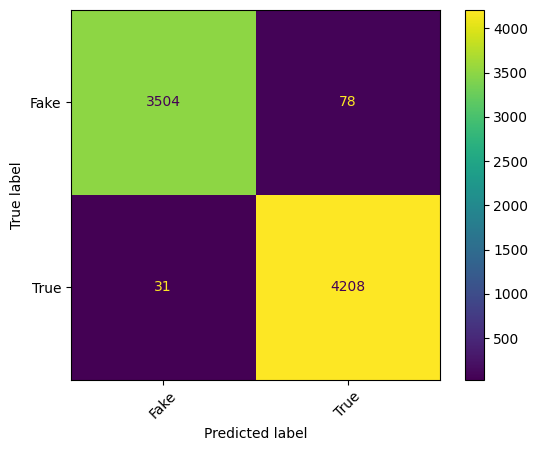

In [46]:
ConfusionMatrixDisplay.from_estimator(lr,
                                       X_test_tfidf,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Fake', 'True']
    );

#### XGBoost

In [48]:
xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.7 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
train(xgboost,"Xgboost", X_train_tfidf, y_train, X_test_tfidf, y_test)
class_report(xgboost, X_test_tfidf, y_test)

Xgboost model score on Training data: 99.75067126965861%
Xgboost model score on Testing data: 99.62920342667178%
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      3582
        True       0.99      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821



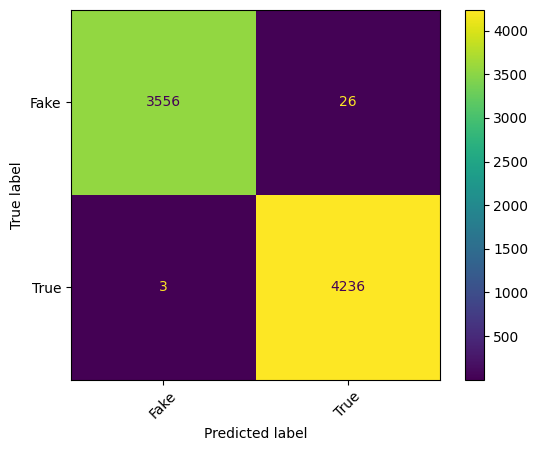

In [51]:
ConfusionMatrixDisplay.from_estimator(xgboost,
                                       X_test_tfidf,
                                       y_test,
                                       xticks_rotation=45,
                                       display_labels=['Fake', 'True']
    );